In [437]:
matplotlib.use('Agg')
%matplotlib inline

In [438]:
def get_daily_return(df):
    df['daily_return']=df.account_value.pct_change(1)
    #df=df.dropna()
    print('Sharpe: ',(252**0.5)*df['daily_return'].mean()/ df['daily_return'].std())
    return df

In [439]:
def backtest_strat(df):
    strategy_ret= df.copy()
    strategy_ret['Date'] = pd.to_datetime(strategy_ret['Date'])
    strategy_ret.set_index('Date', drop = False, inplace = True)
    strategy_ret.index = strategy_ret.index.tz_localize('UTC')
    del strategy_ret['Date']
    ts = pd.Series(strategy_ret['daily_return'].values, index=strategy_ret.index)
    return ts

In [440]:
def get_pre_vix_account_value(model_name):
    dataframes = []  # Use a list to store individual DataFrames

    # Collect all individual DataFrames
    for i in range(rebalance_window + validation_window, len(unique_trade_date) + 1, rebalance_window):
        temp = pd.read_csv(f'pre_vix_results/account_value_trade_{model_name}_{i}.csv')
        dataframes.append(temp)  # Append to list

    # Efficiently concatenate all DataFrames at once
    df_account_value = pd.concat(dataframes, ignore_index=True)

    # Rename column and calculate Sharpe ratio
    df_account_value = pd.DataFrame({'account_value': df_account_value['0']})
    daily_returns = df_account_value['account_value'].pct_change(1)
    sharpe = (252 ** 0.5) * daily_returns.mean() / daily_returns.std()
    print(sharpe)

    # Join with trade dates
    df_account_value = df_account_value.join(df_trade_date[63:].reset_index(drop=True))

    return df_account_value


In [441]:
def get_post_vix_account_value(model_name):
    dataframes = []  # Use a list to store individual DataFrames

    # Collect all individual DataFrames
    for i in range(rebalance_window + validation_window, len(unique_trade_date) + 1, rebalance_window):
        temp = pd.read_csv(f'results/account_value_trade_{model_name}_{i}.csv')
        dataframes.append(temp)  # Append to list

    # Efficiently concatenate all DataFrames at once
    df_account_value = pd.concat(dataframes, ignore_index=True)

    # Rename column and calculate Sharpe ratio
    df_account_value = pd.DataFrame({'account_value': df_account_value['0']})
    daily_returns = df_account_value['account_value'].pct_change(1)
    sharpe = (252 ** 0.5) * daily_returns.mean() / daily_returns.std()
    print(sharpe)

    # Join with trade dates
    df_account_value = df_account_value.join(df_trade_date[63:].reset_index(drop=True))

    return df_account_value

## DJIA

In [442]:
dji = pd.read_csv("data/^DJI.csv")
test_dji=dji[(dji['Date']>='2016-01-01') & (dji['Date']<='2025-06-30')]
test_dji = test_dji.reset_index(drop=True)

In [443]:
test_dji.shape

(1166, 7)

In [444]:
test_dji.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2016-01-04,17405.480469,17405.480469,16957.630859,17148.939453,17148.939453,148060000
1,2016-01-05,17147.500000,17195.839844,17038.609375,17158.660156,17158.660156,105750000
2,2016-01-06,17154.830078,17154.830078,16817.619141,16906.509766,16906.509766,120250000
3,2016-01-07,16888.359375,16888.359375,16463.630859,16514.099609,16514.099609,176240000
4,2016-01-08,16519.169922,16651.890625,16314.570313,16346.450195,16346.450195,141850000


In [445]:
test_dji['daily_return']=test_dji['Adj Close'].pct_change(1)

In [446]:
dow_strat = backtest_strat(test_dji)

## Ensemble Strategy

In [447]:
df=pd.read_csv('data/dow_30_2009_2020.csv')

In [448]:
rebalance_window = 63
validation_window = 63
unique_trade_date = df[(df.datadate > 20151001)&(df.datadate <= 20200707)].datadate.unique()


In [449]:
df_trade_date = pd.DataFrame({'datadate':unique_trade_date})

In [450]:
pre_vix_ensemble_account_value = get_pre_vix_account_value('ensemble')
post_vix_ensemble_account_value = get_post_vix_account_value('ensemble')

0.7721370951451532
1.0353750142115752


<Axes: >

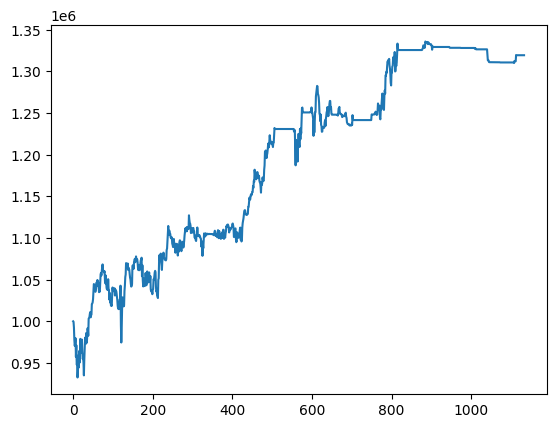

In [451]:
pre_vix_ensemble_account_value.account_value.plot()

<Axes: >

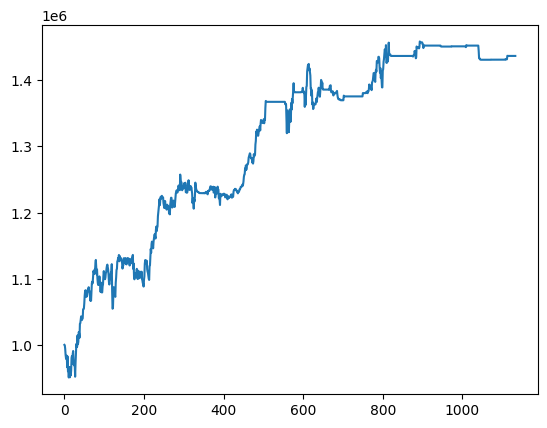

In [452]:
post_vix_ensemble_account_value.account_value.plot()

In [453]:
old_ensemble_account_value = get_daily_return(pre_vix_ensemble_account_value) #before vix changes
new_ensemble_account_value = get_daily_return(post_vix_ensemble_account_value) #after vix changes

Sharpe:  0.7721370951451532
Sharpe:  1.0353750142115752


In [454]:
pre_vix_ensemble_account_value['Date'] = test_dji['Date']
post_vix_ensemble_account_value['Date'] = test_dji['Date']

In [455]:
pre_vix_ensemble_account_value.head()

,account_value,datadate,daily_return,Date
0,1000000.000000,20160104,NaN,2016-01-04
1,999403.924149,20160105,-0.000596,2016-01-05
2,992546.220391,20160106,-0.006862,2016-01-06
3,978274.666770,20160107,-0.014379,2016-01-07
4,970696.929155,20160108,-0.007746,2016-01-08


In [456]:
post_vix_ensemble_account_value.head()

,account_value,datadate,daily_return,Date
0,1000000.000000,20160104,NaN,2016-01-04
1,999324.611649,20160105,-0.000675,2016-01-05
2,994189.782891,20160106,-0.005138,2016-01-06
3,985014.260520,20160107,-0.009229,2016-01-07
4,979988.897905,20160108,-0.005102,2016-01-08


In [457]:
pre_vix_ensemble_strat = backtest_strat(pre_vix_ensemble_account_value[0:1097])

In [458]:
post_vix_ensemble_strat = backtest_strat(post_vix_ensemble_account_value[0:1097])

In [459]:
pre_vix_ensemble_account_value.to_csv('pre_vix_results/df_account_value_ensemble_daily_return.csv',index=False)

In [460]:
post_vix_ensemble_account_value.to_csv('results/df_account_value_ensemble_daily_return.csv',index=False)

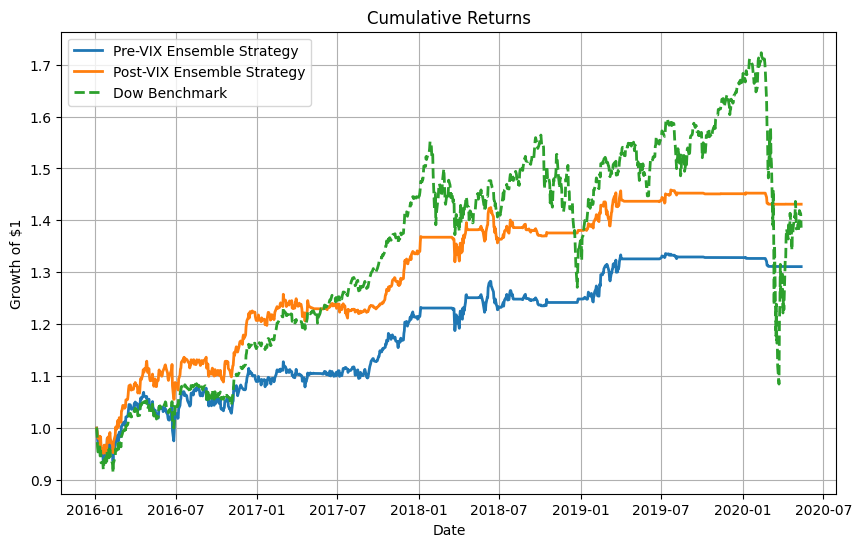

== Pre-VIX Ensemble Strategy ==
Annualized Return:    6.41%
Annualized Volatility: 8.58%
Sharpe Ratio:          0.53
== Post-VIX Ensemble Strategy ==
Annualized Return:    8.58%
Annualized Volatility: 8.24%
Sharpe Ratio:          0.80

== Dow Benchmark ==
Annualized Return:    7.78%
Annualized Volatility: 20.06%
Sharpe Ratio:          0.38


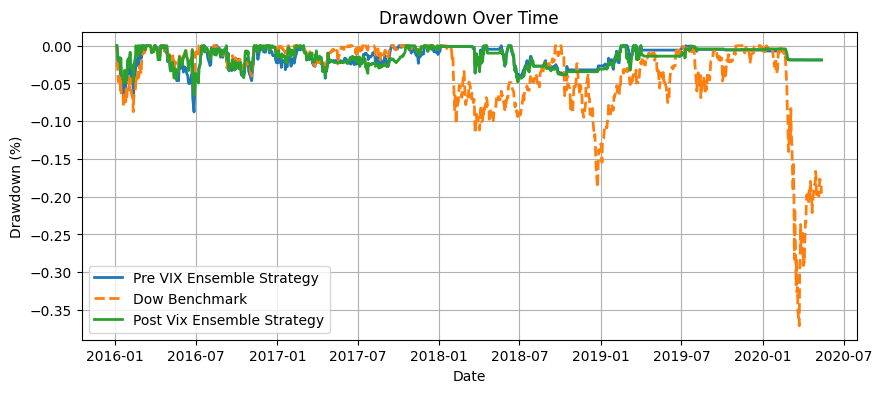

In [461]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###################################
# 1) PREPARE DATA
###################################
# Ensure that ensemble_strat and dow_strat have the same date index
pre_vix_ensemble_strat, dow_strat = pre_vix_ensemble_strat.align(dow_strat, join='inner')
post_vix_ensemble_strat, dow_strat = post_vix_ensemble_strat.align(dow_strat, join='inner')

# Compute cumulative returns for both strategies
pre_vix_ensemble_cum = (1 + pre_vix_ensemble_strat).cumprod()
post_vix_ensemble_cum = (1 + post_vix_ensemble_strat).cumprod()
dow_cum = (1 + dow_strat).cumprod()

###################################
# 2) CUMULATIVE RETURNS PLOT
###################################
plt.figure(figsize=(10, 6))
plt.plot(pre_vix_ensemble_cum.index, pre_vix_ensemble_cum, label='Pre-VIX Ensemble Strategy', linewidth=2)
plt.plot(post_vix_ensemble_cum.index, post_vix_ensemble_cum, label='Post-VIX Ensemble Strategy', linewidth=2)
plt.plot(dow_cum.index, dow_cum, label='Dow Benchmark', linestyle="dashed", linewidth=2)
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

###################################
# 3) PERFORMANCE METRICS
###################################
def annualized_return(returns, freq=252):
    """Compute annualized return from daily returns."""
    total_ret = (1 + returns).prod() - 1
    years = len(returns) / freq
    return (1 + total_ret)**(1 / years) - 1

def annualized_volatility(returns, freq=252):
    """Annualized volatility."""
    return returns.std() * np.sqrt(freq)

def sharpe_ratio(returns, rf_rate=0.02, freq=252):
    """Compute Sharpe Ratio (assuming 2% risk-free rate)."""
    daily_rf = rf_rate / freq
    excess_ret = returns - daily_rf
    return (excess_ret.mean() / excess_ret.std()) * np.sqrt(freq)

pre_ensemble_ar = annualized_return(pre_vix_ensemble_strat)
pre_ensemble_av = annualized_volatility(pre_vix_ensemble_strat)
pre_ensemble_sr = sharpe_ratio(pre_vix_ensemble_strat)

post_ensemble_ar = annualized_return(post_vix_ensemble_strat)
post_ensemble_av = annualized_volatility(post_vix_ensemble_strat)
post_ensemble_sr = sharpe_ratio(post_vix_ensemble_strat)

dow_ar = annualized_return(dow_strat)
dow_av = annualized_volatility(dow_strat)
dow_sr = sharpe_ratio(dow_strat)

print("== Pre-VIX Ensemble Strategy ==")
print(f"Annualized Return:    {pre_ensemble_ar:.2%}")
print(f"Annualized Volatility: {pre_ensemble_av:.2%}")
print(f"Sharpe Ratio:          {pre_ensemble_sr:.2f}")

print("== Post-VIX Ensemble Strategy ==")
print(f"Annualized Return:    {post_ensemble_ar:.2%}")
print(f"Annualized Volatility: {post_ensemble_av:.2%}")
print(f"Sharpe Ratio:          {post_ensemble_sr:.2f}")

print("\n== Dow Benchmark ==")
print(f"Annualized Return:    {dow_ar:.2%}")
print(f"Annualized Volatility: {dow_av:.2%}")
print(f"Sharpe Ratio:          {dow_sr:.2f}")

###################################
# 4) DRAWDOWN PLOT
###################################
def drawdown(returns):
    """Compute the percentage drawdown."""
    cum_returns = (1 + returns).cumprod()
    high_watermark = cum_returns.cummax()
    dd = (cum_returns - high_watermark) / high_watermark
    return dd

ensemble_pre_dd = drawdown(pre_vix_ensemble_strat)
ensemble_post_dd = drawdown(post_vix_ensemble_strat)
dow_dd = drawdown(dow_strat)

plt.figure(figsize=(10, 4))
plt.plot(ensemble_pre_dd.index, ensemble_pre_dd, label='Pre VIX Ensemble Strategy', linewidth=2)
plt.plot(dow_dd.index, dow_dd, label='Dow Benchmark', linestyle="dashed", linewidth=2)
plt.plot(ensemble_post_dd.index, ensemble_post_dd, label='Post Vix Ensemble Strategy', linewidth=2)
plt.title('Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.grid(True)
plt.show()


In [436]:
with pyfolio.plotting.plotting_context(font_scale=1.1):
    pyfolio.create_full_tear_sheet(returns = ensemble_strat,
                                   benchmark_rets=dow_strat, set_context=False)

NameError: name 'pyfolio' is not defined